# Imports

In [187]:
import math
import numpy as np
import pandas as pd
import plotly.express as px
import pickle
import matplotlib.pyplot as plt
import seaborn as sns

# Data Loading

In [188]:
train_data= pd.read_csv("train.csv")

train_data.head()

,x,y
0,24.0,21.549452
1,50.0,47.464463
2,15.0,17.218656
3,38.0,36.586398
4,87.0,87.288984


plot the data here

<Axes: xlabel='x', ylabel='y'>

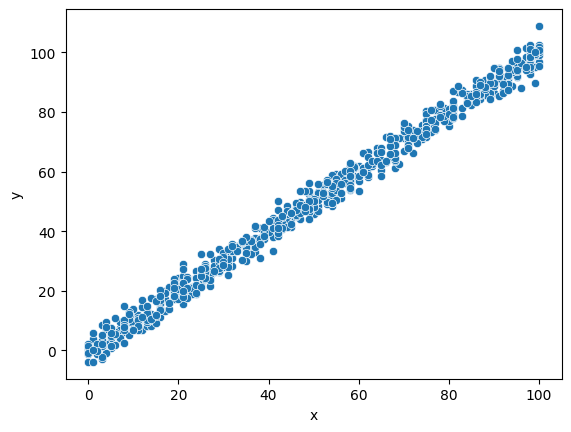

In [189]:
sns.scatterplot(x="x",y="y",data=train_data)

# Data Preprocessing

## Standardize the data
    fill this
### Why Use Standardization in Machine Learning?
 fill this

### How to Standardize Data

    fill this

In [190]:
type(train_data["x"][0])

numpy.float64

In [191]:
#Standardize the data
from sklearn.preprocessing import StandardScaler
X=train_data[["x"]]
y=train_data['y']
scaler=StandardScaler()
scaler.fit_transform(X)

array([[-2.30232429e-01],
       [-3.70466381e-02],
       [-2.97104434e-01],
       [-1.26209311e-01],
       [ 2.37871603e-01],
       [-1.41069757e-01],
       [-3.19395102e-01],
       [ 1.93290267e-01],
       [-2.22802207e-01],
       [-3.71406662e-01],
       [-2.89674211e-01],
       [-2.89674211e-01],
       [-2.30232429e-01],
       [-1.18779088e-01],
       [-7.32574712e-03],
       [ 3.72555893e-02],
       [-2.15371984e-01],
       [ 1.33848485e-01],
       [-1.93081316e-01],
       [-1.78220870e-01],
       [ 9.66973713e-02],
       [ 2.37871603e-01],
       [ 2.23951439e-02],
       [-7.32574712e-03],
       [ 2.15580935e-01],
       [ 2.23951439e-02],
       [-4.44768608e-02],
       [-2.59953320e-01],
       [ 2.60162272e-01],
       [-5.19070836e-02],
       [-3.78836884e-01],
       [-2.22802207e-01],
       [-9.64884200e-02],
       [-4.08557775e-01],
       [ 3.72555893e-02],
       [ 2.82452940e-01],
       [-1.18779088e-01],
       [-3.56546216e-01],
       [-2.5

## Reshaping data for the correct shape for the model

why cant we make the model without reshaping?

# Model Implementation

# Linear Regression Model

Linear regression is a fundamental model in machine learning used for predicting a continuous output variable based on input features. The model function for linear regression is represented as:

$$f_{w,b}(x) = wx + b$$

In this equation, $f_{w,b}(x)$ represents the predicted output, $w$ is the weight parameter, $b$ is the bias parameter, and $x$ is the input feature.

## Model Training

To train a linear regression model, we aim to find the best values for the parameters $(w, b)$ that best fit our dataset.

### Forward Pass

The forward pass is a step where we compute the linear regression output for the input data $X$ using the current weights and biases. It's essentially applying our model to the input data.

### Cost Function

The cost function is used to measure how well our model is performing. It quantifies the difference between the predicted values and the actual values in our dataset. The cost function is defined as:

$$J(w,b) = \frac{1}{2m} \sum_{i=1}^{m}(f_{w,b}(x^{(i)}) - y^{(i)})^2$$

Here, $J(w, b)$ is the cost, $m$ is the number of training examples, $x^{(i)}$ is the input data for the $i$-th example, $y^{(i)}$ is the actual output for the $i$-th example, and $w$ and $b$ are the weight and bias parameters, respectively.

### Backward Pass (Gradient Computation)

The backward pass computes the gradients of the cost function with respect to the weights and biases. These gradients are crucial for updating the model parameters during training. The gradient formulas are as follows:

$$
\frac{\partial J(w,b)}{\partial b} = \frac{1}{m} \sum_{i=0}^{m-1} (f_{w,b}(X^{(i)}) - y^{(i)})
$$

$$
\frac{\partial J(w,b)}{\partial w} = \frac{1}{m} \sum_{i=0}^{m-1} (f_{w,b}(X^{(i)}) - y^{(i)})X^{(i)}
$$

## Training Process

The training process involves iteratively updating the weights and biases to minimize the cost function. This is typically done through an optimization algorithm like gradient descent. The update equations for parameters are:

$$w \leftarrow w - \alpha \frac{\partial J}{\partial w}$$

$$b \leftarrow b - \alpha \frac{\partial J}{\partial b}$$

Here, $\alpha$ represents the learning rate, which controls the step size during parameter updates.

By iteratively performing the forward pass, computing the cost, performing the backward pass, and updating the parameters, the model learns to make better predictions and fit the data.


In [192]:
class LinearRegression:
    
    def __init__(self,):
        self.w=None
        pass
        

    def initialize_parameters(self):
        self.w=np.zeros((self.x.shape[1],1))


    def forward(self,X):
        return np.dot(X, self.w)

    def compute_cost(self,x,y):
        m=y.shape[0]
        cost=np.sum(((np.dot(x,self.w)-y)**2))/(2*m)

        return cost

    # def backward(self,x,y):
    #     m=y.shape[0]
    #     dw=[]
    #     for i in range (x.shape[1]):
    #         a=0
    #         for j in range (len(y)):
    #             a+=(self.forward(x[j])-y)*x[j][i]
    #         dw.append(a/(m))
    #     dw=np.array(dw)
    #     # print(dw)
    #     return dw

    def backward(self, X, y):
        m = y.shape[0]
        predictions = self.forward(X).reshape(-1,1)
        dw = (1/m) * np.dot(X.T, (predictions - y))
        return dw



    def fit(self, X, y, iterations, plot_cost=True,learning_rate=0.01):
        X=np.array(X)
        y=np.array(y).reshape(-1,1)
        b=np.ones(X.shape[0])
        self.x=np.column_stack((b,X))
        self.y=y
        self.initialize_parameters()
        cost_values=[]
        for i in range (iterations):
            self.w= self.w-learning_rate*self.backward(self.x,self.y)
            # print(self.compute_cost(self.x,self.y))
            cost_values.append(self.compute_cost(self.x,self.y))
            
        if plot_cost:
            plt.plot(range(iterations), cost_values)
            plt.xlabel("Iterations")
            plt.ylabel("Cost")
            print(len(cost_values))

    def predict(self, X):
        b = np.ones((X.shape[0], 1))
        X = np.column_stack((b, X))
        return np.dot(X, self.w)

    
    def save_model(self, filename="linear_regression_model.pkl"):
        with open(filename, 'wb') as file:
            pickle.dump(self.w, file)
        print(f" Model saved as '{filename}' successfully!")


    @classmethod
    def load_model(cls, filename="linear_regression_model.pkl"):
        # Create a new instance of LinearRegression
        model = cls()
        # Load the weights from the file
        with open(filename, 'rb') as file:
            model.w = pickle.load(file)
        print(f" Model loaded from '{filename}' successfully!")
        return model


    

    

(525, 1)
1000
[[0.01499828]
 [0.99898307]]


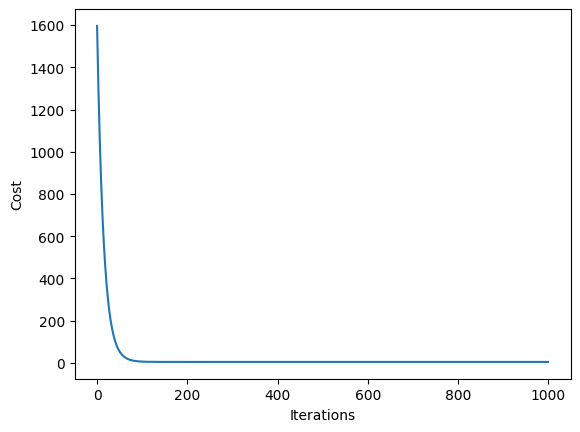

In [198]:
#train test split was a stupid thing to do but the code is not running otherwise 



from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
print(X_train.shape)

test_data=pd.read_csv("test.csv")
X_test, y_test =test_data['x'],test_data['y']

lr = LinearRegression()
lr.fit(X_train, y_train, iterations=1000,learning_rate=0.00001,plot_cost=True)
print(lr.w)

In [194]:
lr.save_model('model.pkl')

 Model saved as 'model.pkl' successfully!


# Evaluation



### 1. Mean Squared Error (MSE)

**Formula:**
$$
\text{MSE} = \frac{1}{n} \sum_{i=1}^{n} (y_{\text{true}_i} - y_{\text{pred}_i})^2
$$

**Description:**
 MSE (Mean Squared Error) is a metric used to measure the average squared difference between the actual (true) values y_true and the predicted values y_pred

It calculates how close the predictions are to the actual output.
The errors are squared to ensure that large errors are penalized more than smaller errors.

**Interpretation:**
ower MSE indicates better model performance (predictions are closer to actual values).

Higher MSE means poor model performance.

MSE has the same unit as the square of the target variable.

### 2. Root Mean Squared Error (RMSE)

**Formula:**
$$
\text{RMSE} = \sqrt{\text{MSE}}
$$

**Description:**
Root Mean Squared Error (RMSE) is simply the square root of MSE.

It measures the standard deviation of the prediction errors (residuals).

RMSE is often preferred in practical problems because it brings the error to the same unit as the target variable, making it easier to interpret.

**Interpretation:**
Lower RMSE indicates better model performance.

Higher RMSE means poor model performance.

It is commonly used when communicating model accuracy to non-technical stakeholders.


### 3. R-squared ($R^2$)

**Formula:**
$$
R^2 = 1 - \frac{\text{SSR}}{\text{SST}}
$$

**Description:**
R-squared (R²) measures the proportion of variance in the target variable that is explained by the model.

It tells how well the model fits the data compared to a baseline model (predicting the mean).

Higher R² means the model explains most of the variability in the target variable.

**Interpretation:**
R² = 1: Perfect model (100% variance explained).

R² = 0: Model performs as bad as predicting the mean value.

R² < 0: Model is worse than simply predicting the mean.


In [195]:
class RegressionMetrics:
    @staticmethod
    def mean_squared_error(y_true, y_pred):
        """
        Calculate the Mean Squared Error (MSE).

        Args:
            y_true (numpy.ndarray): The true target values.
            y_pred (numpy.ndarray): The predicted target values.

        Returns:
            float: The Mean Squared Error.
        """
        mse = np.mean((y_true - y_pred)**2)
        return mse
        
    @staticmethod
    def root_mean_squared_error(y_true, y_pred):
        """
        Calculate the Root Mean Squared Error (RMSE).

        Args:
            y_true (numpy.ndarray): The true target values.
            y_pred (numpy.ndarray): The predicted target values.

        Returns:
            float: The Root Mean Squared Error.
        """
        mse = RegressionMetrics.mean_squared_error(y_true, y_pred)
        rmse = np.sqrt(mse)
        return rmse
        
    @staticmethod
    def r_squared(y_true, y_pred):
        """
        Calculate the R-Squared Value
        
        Args:
            y_true (numpy.ndarray): The true target values.
            y_pred (numpy.ndarray): The predicted target values.

        Returns:
            float: The R-Squared Value.
        """
        ssr = np.sum((y_true - y_pred)**2)     # Sum of Squared Residuals
        sst = np.sum((y_true - np.mean(y_true))**2) # Total Sum of Squares
        r2 = 1 - (ssr / sst)
        return r2


In [196]:
model=LinearRegression.load_model("model.pkl")
y_pred = model.predict(X_test)

y_pred=y_pred.flatten()
mse_value = RegressionMetrics.mean_squared_error(y_test, y_pred)
rmse_value = RegressionMetrics.root_mean_squared_error(y_test, y_pred)
r_squared_value = RegressionMetrics.r_squared(y_test, y_pred)

print(f"Mean Squared Error (MSE): {mse_value}")
print(f"Root Mean Squared Error (RMSE): {rmse_value}")
print(f"R-squared (Coefficient of Determination): {r_squared_value}")

 Model loaded from 'model.pkl' successfully!
Mean Squared Error (MSE): 9.446406175991502
Root Mean Squared Error (RMSE): 3.073500638684089
R-squared (Coefficient of Determination): 0.9887854365467076
